# Feature Importance Practice: Voter Data

## Setup

*Same voter data setup as notebooks 18 and 19.*

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance


In [3]:

# Load and clean
voter_url = 'https://raw.githubusercontent.com/fivethirtyeight/data/master/non-voters/nonvoters_data.csv'
voter_raw = pd.read_csv(voter_url)

voter_clean = voter_raw.drop(columns=['RespId', 'weight', 'Q1']).copy()
voter_clean['educ'] = pd.Categorical(voter_clean['educ'],
    categories=['High school or less', 'Some college', 'College'], ordered=True)
voter_clean['income_cat'] = pd.Categorical(voter_clean['income_cat'],
    categories=['Less than $40k', '$40-75k ', '$75-125k', '$125k or more'], ordered=True)
voter_clean['voter_category'] = pd.Categorical(voter_clean['voter_category'],
    categories=['rarely/never', 'sporadic', 'always'], ordered=False)

voter_clean = voter_clean[voter_clean['Q22'] != 5].copy()
voter_clean['Q22'] = voter_clean['Q22'].fillna('Not Asked').astype(str)

for c in [f'Q28_{i}' for i in range(1, 9)]:
    voter_clean[c] = voter_clean[c].replace(-1.0, 0).fillna('Not Asked').astype(str)
for c in [f'Q29_{i}' for i in range(1, 11)]:
    voter_clean[c] = voter_clean[c].replace(-1.0, 0).fillna('Not Asked').astype(str)

def _party_id(row):
    q31, q32, q33 = row['Q31'], row['Q32'], row['Q33']
    if   q31 == 1: return 'Strong Republican'
    elif q31 == 2: return 'Republican'
    elif q32 == 1: return 'Strong Democrat'
    elif q32 == 2: return 'Democrat'
    elif q33 == 1: return 'Lean Republican'
    elif q33 == 2: return 'Lean Democrat'
    else:          return 'Other'

voter_clean['Party_ID'] = voter_clean.apply(_party_id, axis=1)
party_order = ['Strong Republican', 'Republican', 'Lean Republican',
               'Other', 'Lean Democrat', 'Democrat', 'Strong Democrat']
voter_clean['Party_ID'] = pd.Categorical(voter_clean['Party_ID'],
                                         categories=party_order, ordered=True)
voter_clean = voter_clean.drop(columns=['Q31', 'Q32', 'Q33'])

for c in voter_clean.columns:
    if c != 'ppage' and voter_clean[c].dtype in ['float64', 'int64']:
        voter_clean[c] = voter_clean[c].replace(-1, np.nan)

X_voter = voter_clean.drop(columns=['voter_category'])
y_voter = voter_clean['voter_category']

X_train, X_test, y_train, y_test = train_test_split(
    X_voter, y_voter, test_size=0.3, stratify=y_voter, random_state=4025)

ordered_cat_cols = ['educ', 'income_cat', 'Party_ID']
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
nom_cols = [c for c in X_train.columns
            if c not in ordered_cat_cols and c not in num_cols]

preproc_voter = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median'))]), num_cols),
    ('ord', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ]), ordered_cat_cols),
    ('nom', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
    ]), nom_cols),
], remainder='drop')

print(f"Training: {X_train.shape[0]} obs  |  Test: {X_test.shape[0]} obs")

Training: 4071 obs  |  Test: 1746 obs


/tmp/ipykernel_99198/1078346725.py:8: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  voter_clean['income_cat'] = pd.Categorical(voter_clean['income_cat'],


## Fit Models

Fit three models: Bagging, Random Forest (with `max_features='sqrt'`), and Logistic Regression. All use the same preprocessing pipeline.

In [6]:
# Bagging
bag_pipe = Pipeline([
    ('preproc', preproc_voter),
    ('bag', BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=4025),
        n_estimators=200, oob_score=True, random_state=4025, n_jobs=-1
    ))
])
bag_pipe.fit(X_train, y_train)

# Random Forest
rf_pipe = Pipeline([
    ('preproc', preproc_voter),
    ('rf', RandomForestClassifier(
        n_estimators=200, max_features='sqrt', random_state=4025, n_jobs=-1
    ))
])
rf_pipe.fit(X_train, y_train)

# Logistic Regression
lr_pipe = Pipeline([
    ('preproc', preproc_voter),
    ('lr', LogisticRegression(max_iter=1000, random_state=4025))
])
lr_pipe.fit(X_train, y_train)

for name, pipe in [('Bagging', bag_pipe), ('Random Forest', rf_pipe), ('Logistic Reg.', lr_pipe)]:
    print(f"{name:15s}  test acc = {accuracy_score(y_test, pipe.predict(X_test)):.3f}")

/home/efriedlander/miniforge3/envs/math-4025-sp26/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Bagging          test acc = 0.643
Random Forest    test acc = 0.625
Logistic Reg.    test acc = 0.584


## Helper: Get Feature Names

Build the full list of feature names after preprocessing — used for all importance plots.

In [7]:
def get_feature_names(pipe):
    enc = pipe.named_steps['preproc'].named_transformers_['nom'].named_steps['encode']
    return num_cols + ordered_cat_cols + list(enc.get_feature_names_out(nom_cols))

feature_names = get_feature_names(bag_pipe)  # same for all three pipes
print(f"{len(feature_names)} features after encoding")

139 features after encoding


## MDI: Mean Decrease in Impurity

MDI is built into tree-based models. It measures how much each feature reduces node impurity across all splits and all trees.

### MDI: Bagging

For `BaggingClassifier`, we average `feature_importances_` manually across all trees.

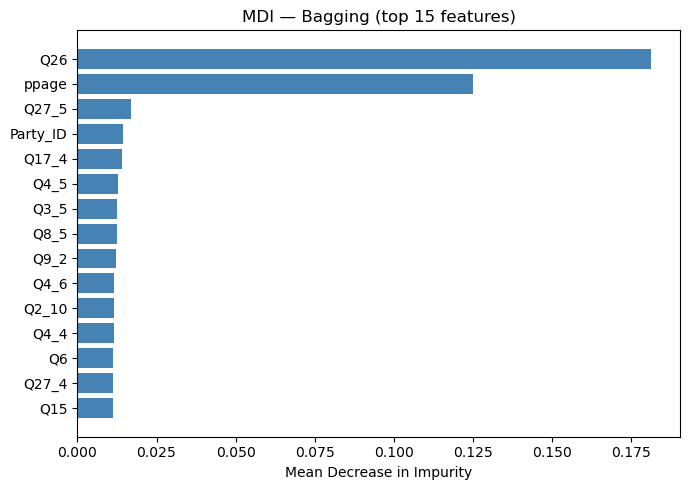

In [8]:
bag_mdi = np.mean([t.feature_importances_
                   for t in bag_pipe.named_steps['bag'].estimators_], axis=0)

imp_bag = (pd.DataFrame({'feature': feature_names, 'importance': bag_mdi})
           .sort_values('importance', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp_bag['feature'][::-1], imp_bag['importance'][::-1], color='steelblue')
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_title('MDI — Bagging (top 15 features)')
plt.tight_layout()
plt.show()

### MDI: Random Forest

`RandomForestClassifier` stores the aggregated importances directly — no manual averaging needed.

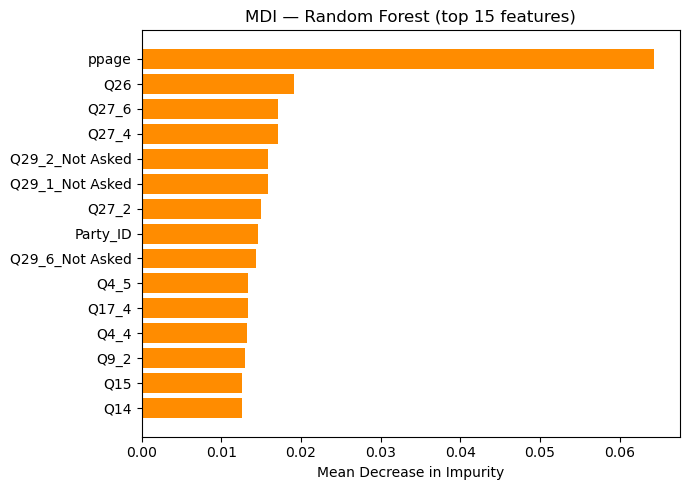

In [9]:
rf_mdi = rf_pipe.named_steps['rf'].feature_importances_

imp_rf = (pd.DataFrame({'feature': feature_names, 'importance': rf_mdi})
          .sort_values('importance', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp_rf['feature'][::-1], imp_rf['importance'][::-1], color='darkorange')
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_title('MDI — Random Forest (top 15 features)')
plt.tight_layout()
plt.show()

## Permutation Importance

Permutation importance works with **any** model. For each feature:
1. Shuffle that feature's values in the **test set**
2. Measure the drop in accuracy compared to the unshuffled baseline
3. Repeat `n_repeats` times and average

A large drop means the model relied heavily on that feature. Features with near-zero or negative drops are not contributing.

### Permutation Importance: Bagging

In [10]:
perm_bag = permutation_importance(
    bag_pipe, X_test, y_test,
    n_repeats=10, random_state=4025, n_jobs=-1
)

perm_bag_df = (pd.DataFrame({
    'feature': feature_names,
    'mean': perm_bag.importances_mean,
    'std':  perm_bag.importances_std
}).sort_values('mean', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(perm_bag_df['feature'][::-1], perm_bag_df['mean'][::-1],
        xerr=perm_bag_df['std'][::-1], color='steelblue', capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean Accuracy Drop (± 1 SD)')
ax.set_title('Permutation Importance — Bagging (top 15)')
plt.tight_layout()
plt.show()

ValueError: All arrays must be of the same length

### Permutation Importance: Random Forest

In [ ]:
perm_rf = permutation_importance(
    rf_pipe, X_test, y_test,
    n_repeats=10, random_state=4025, n_jobs=-1
)

perm_rf_df = (pd.DataFrame({
    'feature': feature_names,
    'mean': perm_rf.importances_mean,
    'std':  perm_rf.importances_std
}).sort_values('mean', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(perm_rf_df['feature'][::-1], perm_rf_df['mean'][::-1],
        xerr=perm_rf_df['std'][::-1], color='darkorange', capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean Accuracy Drop (± 1 SD)')
ax.set_title('Permutation Importance — Random Forest (top 15)')
plt.tight_layout()
plt.show()

### Permutation Importance: Logistic Regression

Logistic Regression has no `feature_importances_` attribute, so permutation importance is the natural way to assess which features matter.

In [ ]:
perm_lr = permutation_importance(
    lr_pipe, X_test, y_test,
    n_repeats=10, random_state=4025, n_jobs=-1
)

perm_lr_df = (pd.DataFrame({
    'feature': feature_names,
    'mean': perm_lr.importances_mean,
    'std':  perm_lr.importances_std
}).sort_values('mean', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(perm_lr_df['feature'][::-1], perm_lr_df['mean'][::-1],
        xerr=perm_lr_df['std'][::-1], color='seagreen', capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean Accuracy Drop (± 1 SD)')
ax.set_title('Permutation Importance — Logistic Regression (top 15)')
plt.tight_layout()
plt.show()

## Comparison: Top Features Across Models

Rank each feature by its permutation importance, then compare ranks across all three models. Features that rank highly across all models are more trustworthy signals.

In [ ]:
top_n = 12

# Union of top features from all three permutation results
top_features = list(dict.fromkeys(
    list(perm_bag_df['feature'].head(top_n)) +
    list(perm_rf_df['feature'].head(top_n)) +
    list(perm_lr_df['feature'].head(top_n))
))

def perm_means(perm_result):
    return dict(zip(feature_names, perm_result.importances_mean))

bag_means = perm_means(perm_bag)
rf_means  = perm_means(perm_rf)
lr_means  = perm_means(perm_lr)

compare_df = pd.DataFrame({
    'feature':       top_features,
    'Bagging':       [bag_means[f] for f in top_features],
    'Random Forest': [rf_means[f]  for f in top_features],
    'Logistic Reg.': [lr_means[f]  for f in top_features],
}).set_index('feature').sort_values('Random Forest', ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(compare_df))
w = 0.25
ax.barh(x - w, compare_df['Bagging'],       w, label='Bagging',        color='steelblue')
ax.barh(x,     compare_df['Random Forest'],  w, label='Random Forest',  color='darkorange')
ax.barh(x + w, compare_df['Logistic Reg.'],  w, label='Logistic Reg.',  color='seagreen')
ax.set_yticks(x)
ax.set_yticklabels(compare_df.index)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean Accuracy Drop (Permutation Importance)')
ax.set_title('Feature Importance Comparison Across Models')
ax.legend()
plt.tight_layout()
plt.show()